**A DATA-DRIVEN COMPARISON OF MACHINE LEARNING MODELS FOR PREDICTING EMPLOYEE ATTRITION INTENTION**

02 — Exploratory Data Analysis (EDA)

This notebook covers visual exploration of the survey dataset including attrition intention distribution, age group analysis, job satisfaction, environment satisfaction, work-life balance, overtime, job level, marital status, correlation heatmap, and dataset verification statistics.

**3. Exploratory Data Analysis (EDA)**

Visual exploration of the dataset to understand the distribution of responses and identify key patterns related to attrition intention.

3.1 Attrition Intention Distribution

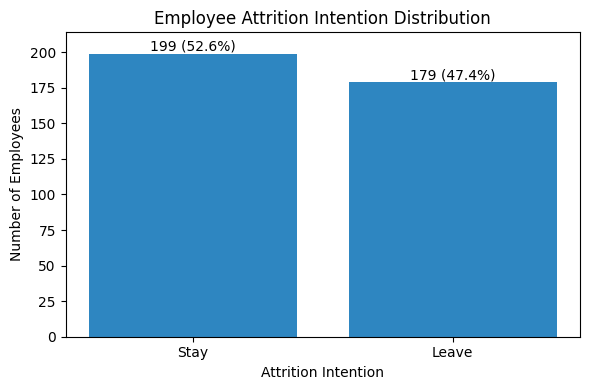

In [ ]:
counts = data["AttritionIntention"].value_counts().sort_index()

plt.figure(figsize=(6,4))

bars = plt.bar(counts.index, counts.values, color="#2E86C1")

plt.title("Employee Attrition Intention Distribution", fontsize=12)
plt.xlabel("Attrition Intention")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["Stay", "Leave"])

total = counts.sum()

for bar in bars:
    yval = bar.get_height()
    percent = (yval / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             f"{int(yval)} ({percent:.1f}%)",
             ha="center", fontsize=10)

plt.ylim(0, max(counts.values) + 15)

plt.tight_layout()
plt.show()

3.2 Age Group vs Attrition Intention

In [ ]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 25, 35, 45, 70],
    labels=["18-25", "26-35", "36-45", "46-70"]
)

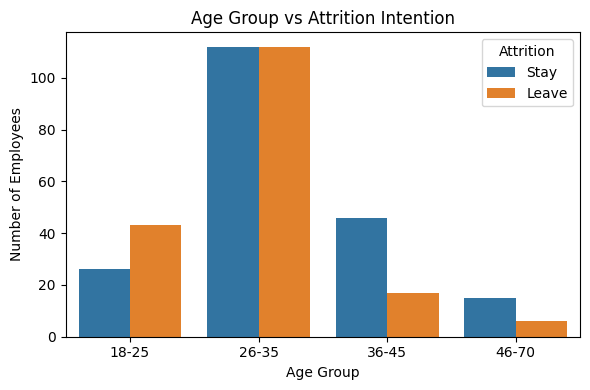

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="AgeGroup",
    hue="AttritionIntention",
    data=data
)

plt.title("Age Group vs Attrition Intention")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.3 Job Satisfaction vs Attrition Intention

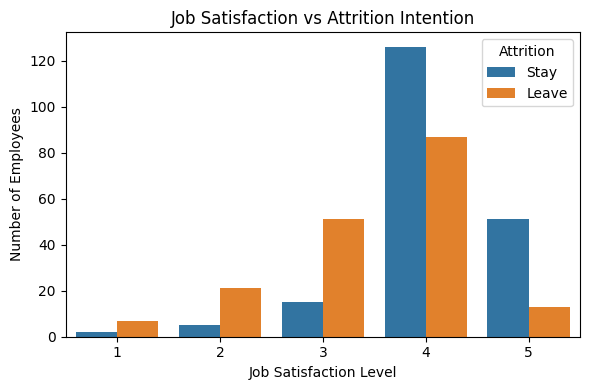

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction", hue="AttritionIntention", data=data)

plt.title("Job Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# Job Satisfaction vs Attrition
print("Job Satisfaction vs Attrition Intention:")
print(data.groupby("JobSatisfaction")[target_col].value_counts().unstack(fill_value=0))
print()
print(data.groupby("JobSatisfaction")[target_col].value_counts(normalize=True).unstack(fill_value=0).round(3) * 100)

Job Satisfaction vs Attrition Intention:
AttritionIntention    0   1
JobSatisfaction            
1                     2   7
2                     5  21
3                    15  51
4                   126  87
5                    51  13

AttritionIntention     0     1
JobSatisfaction               
1                   22.2  77.8
2                   19.2  80.8
3                   22.7  77.3
4                   59.2  40.8
5                   79.7  20.3


3.4 Environment Satisfaction vs Attrition Intention

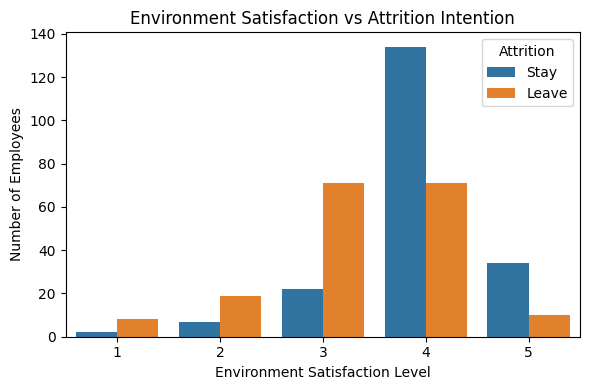

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="EnvironmentSatisfaction",
    hue="AttritionIntention",
    data=data
)

plt.title("Environment Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.5 Work-Life Balance vs Attrition Intention

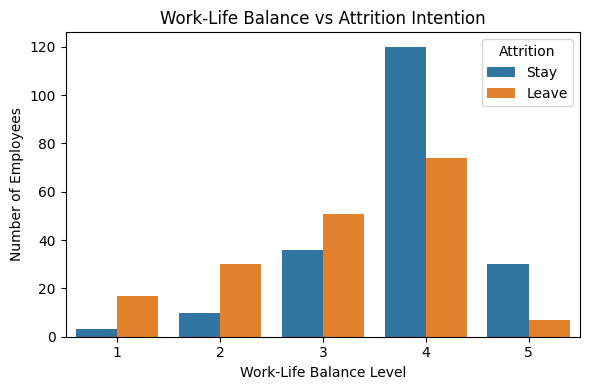

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="WorkLifeBalance",
    hue="AttritionIntention",
    data=data
)

plt.title("Work-Life Balance vs Attrition Intention", fontsize=12)
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.6 Overtime vs Attrition Intention

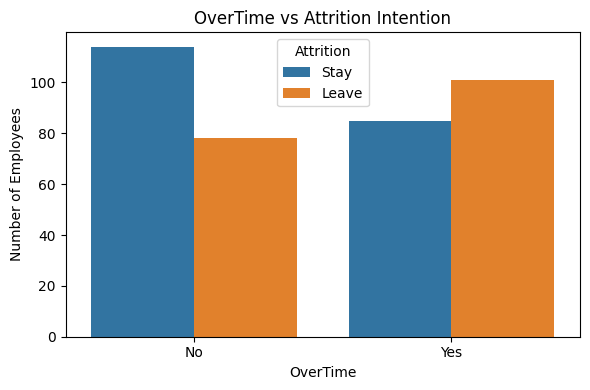

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OverTime",
    hue="AttritionIntention",
    data=data
)

plt.title("OverTime vs Attrition Intention", fontsize=12)
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["No", "Yes"])

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.7 Job Level vs Attrition Intention



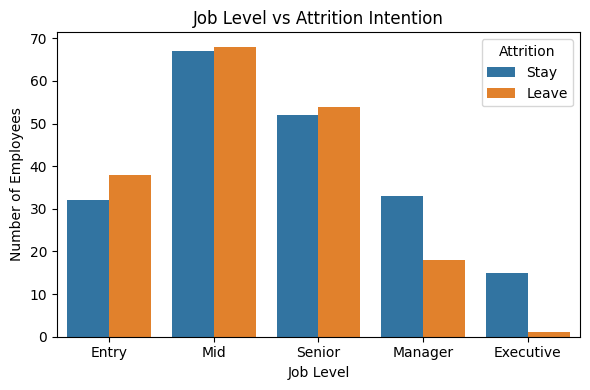

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

# Target column fix
data["AttritionIntention"] = data["AttritionIntention"].astype(int)

# Job level mapping
data["JobLevelLabel"] = data["JobLevel"].map({
    1: "Entry",
    2: "Mid",
    3: "Senior",
    4: "Manager",
    5: "Executive"
})

data = data.dropna(subset=["JobLevelLabel"])

plt.figure(figsize=(6,4))

sns.countplot(
    x="JobLevelLabel",
    hue="AttritionIntention",
    data=data,
    order=["Entry","Mid","Senior","Manager","Executive"]
)

plt.title("Job Level vs Attrition Intention", fontsize=12)
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.8 Marital Status vs Attrition Intention

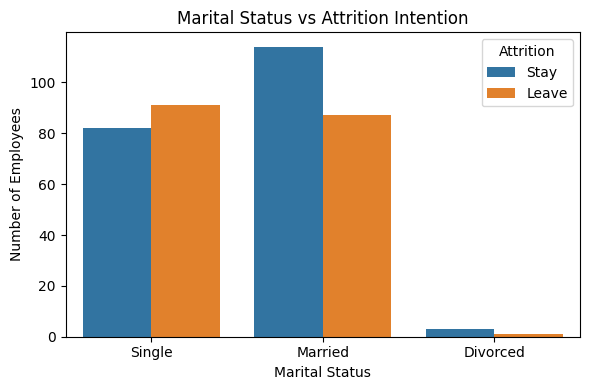

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="MaritalStatus",
    hue="AttritionIntention",
    data=data
)

plt.title("Marital Status vs Attrition Intention", fontsize=12)
plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.xticks([0, 1, 2], ["Single", "Married", "Divorced"])
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.9 Correlation Heatmap

Correlation between key satisfaction variables and attrition intention.

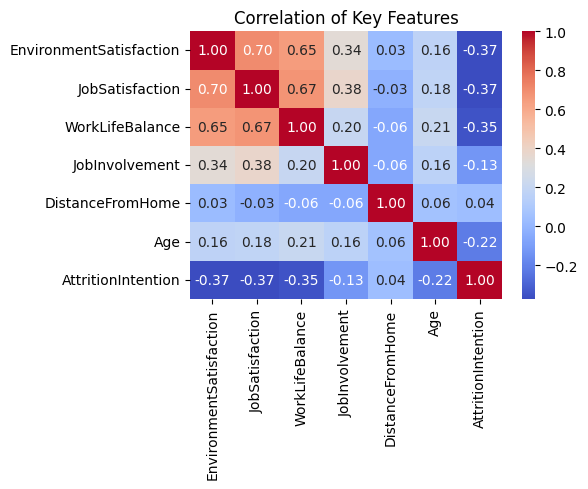

In [ ]:
important_cols = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "DistanceFromHome",
    "Age",
    "AttritionIntention"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    data[important_cols].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation of Key Features")
plt.tight_layout()
plt.show()

In [ ]:
corr = data[['EnvironmentSatisfaction', 'JobSatisfaction',
             'WorkLifeBalance', 'JobInvolvement',
             'DistanceFromHome', 'Age',
             'AttritionIntention']].corr()
print(corr['AttritionIntention'].round(2))

EnvironmentSatisfaction   -0.37
JobSatisfaction           -0.37
WorkLifeBalance           -0.35
JobInvolvement            -0.13
DistanceFromHome           0.04
Age                       -0.22
AttritionIntention         1.00
Name: AttritionIntention, dtype: float64


**7. Dataset Verification Repor**

This section verifies all dataset statistics reported in the thesis including total records, missing values, class distribution, demographic breakdowns and satisfaction means by attrition intention.

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. LOAD DATA
# =========================================================
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# =========================================================
# 2. CLEAN TARGET
# =========================================================
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

print("="*60)
print("COMPLETE DATASET VERIFICATION REPORT")
print("="*60)

print(f"\nTotal Records: {len(data)}")
print(f"Total Variables: {len(data.columns)}")
print(f"Missing Values: {data.isnull().sum().sum()}")

print(f"\nTarget Variable Distribution:")
print(f"Stay (0): {data[target_col].value_counts()[0]} ({round(data[target_col].value_counts()[0]/len(data)*100,1)}%)")
print(f"Leave (1): {data[target_col].value_counts()[1]} ({round(data[target_col].value_counts()[1]/len(data)*100,1)}%)")

# =========================================================
# 3. HELPER FUNCTION
# =========================================================
def show_table(data, col, label_map, title):
    print(f"\n{'='*60}")
    print(f"TABLE: {title}")
    print(f"{'='*60}")
    temp = data.copy()
    temp["_label"] = temp[col].map(label_map)
    table = temp.groupby("_label")[target_col].value_counts().unstack(fill_value=0)
    table.columns = ["Stay", "Leave"]
    table["Total"] = table["Stay"] + table["Leave"]
    table["Stay %"] = round(table["Stay"] / table["Total"] * 100, 1)
    table["Leave %"] = round(table["Leave"] / table["Total"] * 100, 1)
    table["% of Total"] = round(table["Total"] / len(data) * 100, 1)
    print(table.to_string())

# =========================================================
# 4. GENDER TABLE
# =========================================================
show_table(data, "Gender",
    {0: "Male", 1: "Female"},
    "Gender vs Attrition Intention")

# =========================================================
# 5. MARITAL STATUS TABLE
# =========================================================
show_table(data, "MaritalStatus",
    {0: "Single", 1: "Married", 2: "Divorced"},
    "Marital Status vs Attrition Intention")

# =========================================================
# 6. EDUCATION TABLE
# =========================================================
show_table(data, "Education",
    {1: "Diploma", 2: "Bachelor", 3: "Master", 4: "PhD", 5: "Other"},
    "Education Level vs Attrition Intention")

# =========================================================
# 7. EDUCATION FIELD TABLE
# =========================================================
show_table(data, "EducationField",
    {1: "IT/CS", 2: "Engineering", 3: "Business", 4: "Medical", 5: "Other"},
    "Education Field vs Attrition Intention")

# =========================================================
# 8. DEPARTMENT TABLE
# =========================================================
show_table(data, "Department",
    {1: "Engineering", 2: "IT", 3: "Sales", 4: "R&D", 5: "Other"},
    "Department vs Attrition Intention")

# =========================================================
# 9. JOB LEVEL TABLE
# =========================================================
show_table(data, "JobLevel",
    {1: "Entry", 2: "Mid", 3: "Senior", 4: "Manager", 5: "Executive"},
    "Job Level vs Attrition Intention")

# =========================================================
# 10. JOB ROLE TABLE
# =========================================================
show_table(data, "JobRole",
    {1: "Technical/Engineering", 2: "Management",
     3: "Finance", 4: "HR", 5: "Other"},
    "Job Role vs Attrition Intention")

# =========================================================
# 11. OVERTIME TABLE
# =========================================================
show_table(data, "OverTime",
    {0: "No Overtime", 1: "Overtime"},
    "Overtime vs Attrition Intention")

# =========================================================
# 12. DAILY WORK TRAVEL TABLE
# =========================================================
show_table(data, "DailyWorkTravel",
    {1: "Never", 2: "Rarely", 3: "Occasionally",
     4: "Frequently", 5: "Very Frequently"},
    "Daily Work Travel vs Attrition Intention")

# =========================================================
# 13. DISTANCE FROM HOME TABLE
# =========================================================
show_table(data, "DistanceFromHome",
    {1: "0-5 km", 2: "6-15 km", 3: "16-30 km",
     4: "31-50 km", 5: "50+ km"},
    "Distance From Home vs Attrition Intention")

# =========================================================
# 14. MONTHLY INCOME TABLE
# =========================================================
show_table(data, "MonthlyIncome",
    {1: "Very Low", 2: "Low", 3: "Medium",
     4: "High", 5: "Very High"},
    "Monthly Income vs Attrition Intention")

# =========================================================
# 15. PERCENT SALARY HIKE TABLE
# =========================================================
show_table(data, "PercentSalaryHike",
    {1: "No Hike", 2: "1-5%", 3: "6-10%",
     4: "11-20%", 5: "Above 20%"},
    "Percent Salary Hike vs Attrition Intention")

# =========================================================
# 16. WORK LIFE BALANCE TABLE
# =========================================================
show_table(data, "WorkLifeBalance",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Work-Life Balance vs Attrition Intention")

# =========================================================
# 17. ENVIRONMENT SATISFACTION TABLE
# =========================================================
show_table(data, "EnvironmentSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Environment Satisfaction vs Attrition Intention")

# =========================================================
# 18. JOB SATISFACTION TABLE
# =========================================================
show_table(data, "JobSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Job Satisfaction vs Attrition Intention")

# =========================================================
# 19. JOB INVOLVEMENT TABLE
# =========================================================
show_table(data, "JobInvolvement",
    {1: "Not Involved", 2: "Low", 3: "Moderate",
     4: "High", 5: "Extremely Involved"},
    "Job Involvement vs Attrition Intention")

# =========================================================
# 20. COLLEAGUE RELATIONSHIP SATISFACTION TABLE
# =========================================================
show_table(data, "ColleagueRelationshipSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Colleague Relationship Satisfaction vs Attrition Intention")

# =========================================================
# 21. AGE GROUP TABLE
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Age Group vs Attrition Intention")
print(f"{'='*60}")
bins = [0, 25, 35, 45, 100]
labels = ["18-25", "26-35", "36-45", "46-70"]
data["AgeGroup"] = pd.cut(data["Age"], bins=bins, labels=labels)
age_table = data.groupby("AgeGroup")[target_col].value_counts().unstack(fill_value=0)
age_table.columns = ["Stay", "Leave"]
age_table["Total"] = age_table["Stay"] + age_table["Leave"]
age_table["Stay %"] = round(age_table["Stay"] / age_table["Total"] * 100, 1)
age_table["Leave %"] = round(age_table["Leave"] / age_table["Total"] * 100, 1)
age_table["% of Total"] = round(age_table["Total"] / len(data) * 100, 1)
print(age_table.to_string())

# =========================================================
# 22. NUMERICAL VARIABLES SUMMARY
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Numerical Variables Summary")
print(f"{'='*60}")
num_cols = ["Age", "TotalWorkExperience", "YearsAtCompany",
            "YearsInCurrentRole", "YearsSinceLastPromotion",
            "TrainingProgramsLastYear"]
available = [c for c in num_cols if c in data.columns]
print(data[available].describe().round(2).to_string())

# =========================================================
# 23. SATISFACTION MEANS BY ATTRITION
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Satisfaction Means by Attrition Intention")
print(f"{'='*60}")
sat_cols = ["EnvironmentSatisfaction", "JobSatisfaction",
            "WorkLifeBalance", "JobInvolvement",
            "ColleagueRelationshipSatisfaction"]
available = [c for c in sat_cols if c in data.columns]
means = data.groupby(target_col)[available].mean().round(2)
means.index = ["Stay", "Leave"]
print(means.to_string())

COMPLETE DATASET VERIFICATION REPORT

Total Records: 378
Total Variables: 24
Missing Values: 0

Target Variable Distribution:
Stay (0): 199 (52.6%)
Leave (1): 179 (47.4%)

TABLE: Gender vs Attrition Intention
        Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                 
Female    71     58    129    55.0     45.0        34.1
Male     128    121    249    51.4     48.6        65.9

TABLE: Marital Status vs Attrition Intention
          Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                   
Divorced     3      1      4    75.0     25.0         1.1
Married    114     87    201    56.7     43.3        53.2
Single      82     91    173    47.4     52.6        45.8

TABLE: Education Level vs Attrition Intention
          Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                   
Bachelor   107    116    223    48.0     52.0        59.0
Diploma   

**8. Correlation Verification**

This section verifies the correlation values between all variables and attrition intention as reported in the thesis correlation heatmap.

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. LOAD DATA
# =========================================================
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# =========================================================
# 2. CLEAN TARGET
# =========================================================
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

# =========================================================
# 3. CORRELATION TABLE ONLY
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Correlation of All Variables with Attrition Intention")
print(f"{'='*60}")

numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()[target_col].drop(target_col).sort_values()
print(corr.round(4).to_string())

print(f"\n{'='*60}")
print("VERIFICATION COMPLETE")
print(f"{'='*60}")


TABLE: Correlation of All Variables with Attrition Intention
JobSatisfaction                     -0.3740
EnvironmentSatisfaction             -0.3716
WorkLifeBalance                     -0.3490
Age                                 -0.2209
ColleagueRelationshipSatisfaction   -0.2029
TotalWorkExperience                 -0.1986
JobLevel                            -0.1639
TrainingProgramsLastYear            -0.1593
JobInvolvement                      -0.1291
PercentSalaryHike                   -0.1211
YearsInCurrentRole                  -0.1197
YearsSinceLastPromotion             -0.1178
EducationField                      -0.1137
MaritalStatus                       -0.1020
MonthlyIncome                       -0.1005
YearsAtCompany                      -0.0995
Department                          -0.0581
JobRole                             -0.0467
Education                           -0.0360
Gender                              -0.0345
DistanceFromHome                     0.0391
DailyWorkTrave

**9. Dataset Summary Statistics Verification**

This section verifies the mean values and class distribution reported in Table 2 of the thesis.

In [ ]:
import pandas as pd

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

# Mean values
print("Mean Age:", round(data["Age"].mean(), 2))
print("Mean Work Experience:", round(data["TotalWorkExperience"].mean(), 2))
print("Mean Years at Company:", round(data["YearsAtCompany"].mean(), 2))

# Range values
print("\nAge Range:", data["Age"].min(), "-", data["Age"].max())
print("Work Experience Range:", data["TotalWorkExperience"].min(), "-", data["TotalWorkExperience"].max())
print("Years at Company Range:", data["YearsAtCompany"].min(), "-", data["YearsAtCompany"].max())

# Class distribution
print("\nClass Distribution:")
print(data["AttritionIntention"].value_counts())
print(data["AttritionIntention"].value_counts(normalize=True).round(3) * 100)

Mean Age: 31.97
Mean Work Experience: 8.26
Mean Years at Company: 4.05

Age Range: 18 - 69
Work Experience Range: 1 - 45
Years at Company Range: 1 - 37

Class Distribution:
AttritionIntention
0    199
1    179
Name: count, dtype: int64
AttritionIntention
0    52.6
1    47.4
Name: proportion, dtype: float64
